In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
from pathlib import Path
from useful_functions import *
import pickle

In [2]:
OII_rest    = lines_vac['OII']
NII_rest    = lines_vac['NII']
Hbeta_rest  = lines_vac['Hbeta']
Halpha_rest = lines_vac['Halpha']
SII_rest    = lines_vac['SII']
CaII_rest   = lines_vac['CaII']
NaD_rest    = lines_vac['NaD']
crop_region = [lines_vac['Halpha'][0]-30, lines_vac['Halpha'][0]+30]

spectra_data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
spectra = Spectrum(spectra_data, color_data)

blue_crit = (spectra.color_criteria(criterion='g-z<1.25', exclude=False)) | (spectra.color_criteria(criterion='g-r<0.75', exclude=False))
qso_crit = spectra.subtype_criteria(subtype='QSO', exclude=True)
spectra.subset(criteria=blue_crit & qso_crit)
Fit = FitSpectrum(spectra)

Fit.shift_to_rest_frame()

In [3]:
save_path = './fitted_results.pkl'

records = []
if os.path.exists(save_path):
    with open(save_path, 'rb') as fin:
        while True:
            try:
                records.append(pickle.load(fin))
            except EOFError:
                break


In [4]:
# for record in records:
#     dz = record['dz']
#     if dz != 0:
#         Fit.shift_to_rest_frame(id=record['id'], dz=dz)

# Searched NaD Absorption Lines

## Detection Rates

In [5]:
systematic_count = 0
inflow_count = 0
outflow_count = 0
no_detection_count = 0
for record in records:
    searched_NaD_type = record['NaD_type']
    if searched_NaD_type == 'systematic' or searched_NaD_type == 'systematic_2':
        systematic_count += 1
    elif searched_NaD_type == 'inflow' or searched_NaD_type == 'inflow_2':
        inflow_count += 1
    elif searched_NaD_type == 'outflow' or searched_NaD_type == 'outflow_2':
        outflow_count += 1
    else:
        no_detection_count += 1

print(f'Systematic: {systematic_count}, Inflow: {inflow_count}, Outflow: {outflow_count}, No Detection: {no_detection_count}')
print(f'NaD Detection Rate: {(inflow_count + outflow_count) / len(records) * 100:.2f}%')
print(f'Inflow Rate: {inflow_count / len(records) * 100:.2f}%')
print(f'Outflow Rate: {outflow_count / len(records) * 100:.2f}%')

Systematic: 110, Inflow: 12, Outflow: 44, No Detection: 27697
NaD Detection Rate: 0.20%
Inflow Rate: 0.04%
Outflow Rate: 0.16%


In [ ]:
inflow_ids = []
inflow_dlams = []
outflow_ids = []
outflow_dlams = []
for record in records:
    NaD_type = record['NaD_type']
    if (NaD_type == 'inflow') or (NaD_type == 'inflow_2'):
        inflow_ids.append(record['id'])
        inflow_dlams.append(record['NaD_params']['dlam'])
    elif (NaD_type == 'outflow') or (NaD_type == 'outflow_2'):
        outflow_ids.append(record['id'])
        outflow_dlams.append(record['NaD_params']['dlam'])

In [7]:
print(inflow_dlams)
print(inflow_ids)

[np.float64(1.3195743810673262), np.float64(1.7272506763145374), np.float64(1.0288513126833467), np.float64(0.9246679676321897), np.float64(0.8798212360447816), np.float64(4.999999999999999), np.float64(2.4661024621512553), np.float64(1.3317202954031888), np.float64(1.8487873252820068), np.float64(0.8624677059756711), np.float64(0.8444806666571348), np.float64(1.5879550613376558)]
[np.int64(39627800319100618), np.int64(39627776285742032), np.int64(39627812264476858), np.int64(39627757516230341), np.int64(39627739413613668), np.int64(39627757709167132), np.int64(39627811962490196), np.int64(39627745520518011), np.int64(39627812138650039), np.int64(39627764092896410), np.int64(39627739900154875), np.int64(39627751954583611)]


In [8]:
print(outflow_dlams)
print(outflow_ids)

[np.float64(-0.8729435157934153), np.float64(-2.2060522031102927), np.float64(-1.0209876877670108), np.float64(-3.111009995848071), np.float64(-0.8542592665430119), np.float64(-2.5043915013869555), np.float64(-1.608287013851668), np.float64(-1.244796348354077), np.float64(-1.4124144228000484), np.float64(-2.103232297974587), np.float64(-2.2265275396601), np.float64(-2.031973931685009), np.float64(-1.3500760029676886), np.float64(-2.0226702286566205), np.float64(-1.3227845369887854), np.float64(-2.1008985748147277), np.float64(-4.999999999999999), np.float64(-1.1379295277137693), np.float64(-0.8660604659651895), np.float64(-2.054610381889155), np.float64(-2.6542807128856154), np.float64(-3.422136856652934), np.float64(-0.9666538727966987), np.float64(-1.2379684382851093), np.float64(-1.5701685885113084), np.float64(-0.8763858807937397), np.float64(-2.029879286720891), np.float64(-1.8957275732884886), np.float64(-1.5283517168535445), np.float64(-0.9361085797432174), np.float64(-1.8369354

In [9]:
dlam_inflow_max_idx = np.argmax(inflow_dlams)
print(f'Max Inflow dlam: {inflow_dlams[dlam_inflow_max_idx]} for ID {inflow_ids[dlam_inflow_max_idx]}')
dlam_outflow_max_idx = np.argmin(outflow_dlams)
print(f'Max Outflow dlam: {outflow_dlams[dlam_outflow_max_idx]} for ID {outflow_ids[dlam_outflow_max_idx]}')

Max Inflow dlam: 4.999999999999999 for ID 39627757709167132
Max Outflow dlam: -4.999999999999999 for ID 39627793838901559


## Inflow Demo

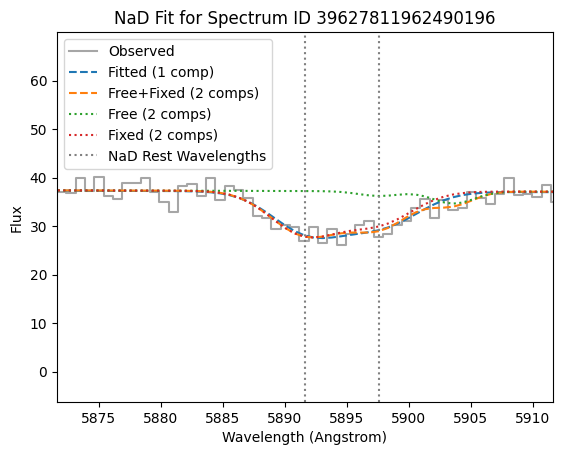

In [21]:
idx = Fit.id2index(39627811962490196)

params_s, status_s = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=False, fit_z=False, e_or_a='a')
fitted_model_s = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_s['gaussian_params'], conti_parms=params_s['conti_params'])

params_d, status_d = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=True, fit_z=False, e_or_a='a')
fitted_model_d = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['gaussian_params'], conti_parms=params_d['conti_params'])
free_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['free_comps'], conti_parms=params_d['conti_params'])
fixed_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['fixed_comps'], conti_parms=params_d['conti_params'])

crop_region = [lines_vac['NaD'][0]-20, lines_vac['NaD'][0]+20]
plt.step(Fit.data_stack[idx, 0, :], Fit.data_stack[idx, 1, :], label='Observed', where='mid', color='gray', alpha=0.7)
plt.plot(Fit.data_stack[idx, 0, :], fitted_model_s, label='Fitted (1 comp)', linestyle='--')
plt.plot(Fit.data_stack[idx, 0, :], fitted_model_d, label='Free+Fixed (2 comps)', linestyle='--')
plt.plot(Fit.data_stack[idx, 0, :], free_model, label='Free (2 comps)', linestyle=':')
plt.plot(Fit.data_stack[idx, 0, :], fixed_model, label='Fixed (2 comps)', linestyle=':')
plt.axvline(x=NaD_rest[0], color='gray', linestyle=':', label='NaD Rest Wavelengths')
plt.axvline(x=NaD_rest[1], color='gray', linestyle=':')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title(f'NaD Fit for Spectrum ID {Fit.targetID[idx]}')
plt.legend()
plt.xlim(crop_region)
# plt.ylim(bottom=10, top=50)
plt.show()

## Outflow Demo

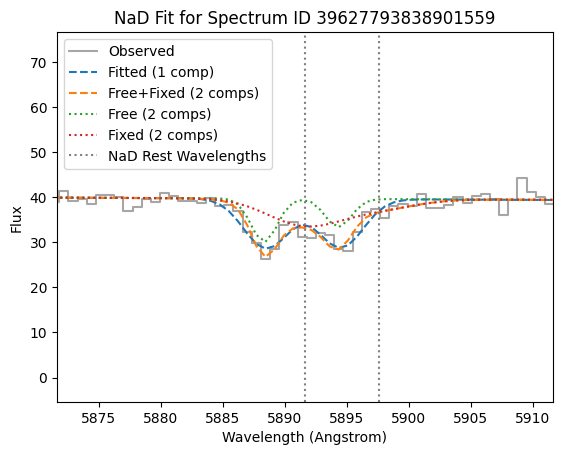

: 

In [ ]:
idx = Fit.id2index(39627793838901559)
params_s, status_s = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=False, fit_z=False, e_or_a='a')
fitted_model_s = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_s['gaussian_params'], conti_parms=params_s['conti_params'])

params_d, status_d = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=True, fit_z=False, e_or_a='a')
fitted_model_d = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['gaussian_params'], conti_parms=params_d['conti_params'])
free_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['free_comps'], conti_parms=params_d['conti_params'])
fixed_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['fixed_comps'], conti_parms=params_d['conti_params'])

crop_region = [lines_vac['NaD'][0]-20, lines_vac['NaD'][0]+20]
plt.step(Fit.data_stack[idx, 0, :], Fit.data_stack[idx, 1, :], label='Observed', where='mid', color='gray', alpha=0.7)
plt.plot(Fit.data_stack[idx, 0, :], fitted_model_s, label='Fitted (1 comp)', linestyle='--')
plt.plot(Fit.data_stack[idx, 0, :], fitted_model_d, label='Free+Fixed (2 comps)', linestyle='--')
plt.plot(Fit.data_stack[idx, 0, :], free_model, label='Free (2 comps)', linestyle=':')
plt.plot(Fit.data_stack[idx, 0, :], fixed_model, label='Fixed (2 comps)', linestyle=':')
plt.axvline(x=NaD_rest[0], color='gray', linestyle=':', label='NaD Rest Wavelengths')
plt.axvline(x=NaD_rest[1], color='gray', linestyle=':')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title(f'NaD Fit for Spectrum ID {Fit.targetID[idx]}')
plt.legend()
plt.xlim(crop_region)
# plt.ylim(bottom=10, top=50)
plt.show()

# P-value from f_stats to Classify Double Peaks

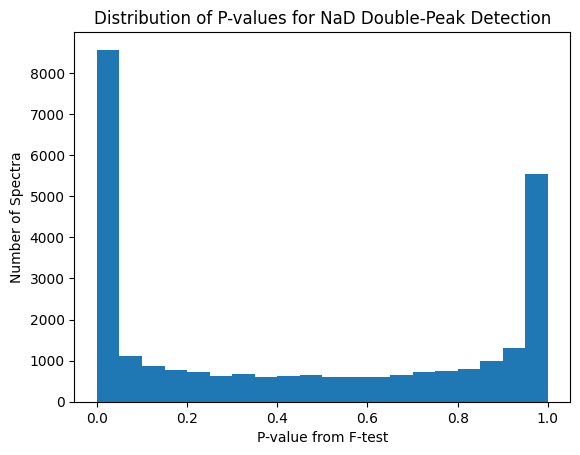

In [12]:
p_values = [record['p_value'] for record in records if record['p_value'] is not None]
plt.hist(p_values, bins=20, range=(0,1))
plt.xlabel('P-value from F-test')
plt.ylabel('Number of Spectra')
plt.title('Distribution of P-values for NaD Double-Peak Detection')
plt.show()

In [18]:
max_p_value_idx = np.argmax(p_values)
print(f'Max P-value: {p_values[max_p_value_idx]}')

min_p_value_idx = np.argmin(p_values)
print(f'Min P-value: {p_values[min_p_value_idx]}')

Max P-value: 1.0
Min P-value: 1.1102230246251565e-16


## Single Peak Demo

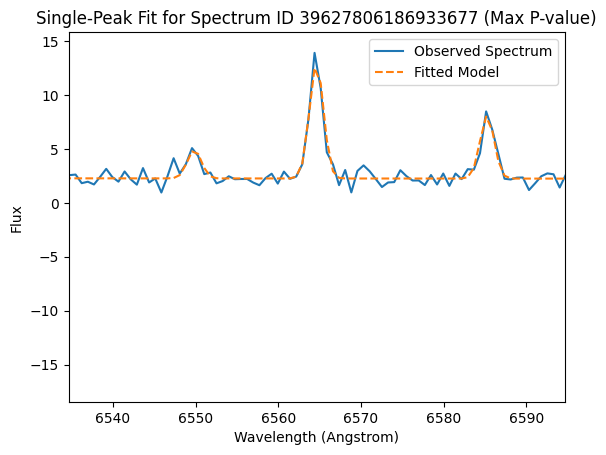

In [19]:
params_s, status_s = Fit.fit_flux(id=Fit.targetID[max_p_value_idx], lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=False, fit_z=True, e_or_a='e')
fitted_model = model(Fit.data_stack[max_p_value_idx, 0, :], gaussian_parms=params_s['gaussian_params'], conti_parms=params_s['conti_params'])
crop_region = [lines_vac['Halpha'][0]-30, lines_vac['Halpha'][0]+30]
plt.plot(Fit.data_stack[max_p_value_idx, 0, :], Fit.data_stack[max_p_value_idx, 1, :], label='Observed Spectrum')
plt.plot(Fit.data_stack[max_p_value_idx, 0, :], fitted_model, label='Fitted Model', linestyle='--')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title(f'Single-Peak Fit for Spectrum ID {Fit.targetID[max_p_value_idx]} (Max P-value)')
plt.legend()
plt.xlim(crop_region)
plt.show()

## Double Peak Demo

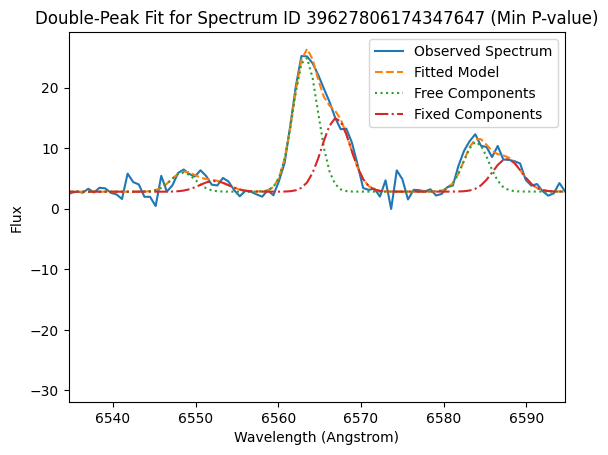

In [20]:
# min_p_value_idx = Fit.id2index(39627757516228442)
params_d, status_d = Fit.fit_flux(id=Fit.targetID[min_p_value_idx], lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=True, fit_z=True, e_or_a='e')
fitted_model_d = model(Fit.data_stack[min_p_value_idx, 0, :], gaussian_parms=params_d['gaussian_params'], conti_parms=params_d['conti_params'])
free_model = model(Fit.data_stack[min_p_value_idx, 0, :], gaussian_parms=params_d['free_comps'], conti_parms=params_d['conti_params'])
fixed_model = model(Fit.data_stack[min_p_value_idx, 0, :], gaussian_parms=params_d['fixed_comps'], conti_parms=params_d['conti_params'])
crop_region = [lines_vac['Halpha'][0]-30, lines_vac['Halpha'][0]+30]
plt.plot(Fit.data_stack[min_p_value_idx, 0, :], Fit.data_stack[min_p_value_idx, 1, :], label='Observed Spectrum')
plt.plot(Fit.data_stack[min_p_value_idx, 0, :], fitted_model_d, label='Fitted Model', linestyle='--')
plt.plot(Fit.data_stack[min_p_value_idx, 0, :], free_model, label='Free Components', linestyle=':')
plt.plot(Fit.data_stack[min_p_value_idx, 0, :], fixed_model, label='Fixed Components', linestyle='-.')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title(f'Double-Peak Fit for Spectrum ID {Fit.targetID[min_p_value_idx]} (Min P-value)')
plt.legend()
plt.xlim(crop_region)
plt.show()